## Trabajo MKT 2

### 1)Importación de librerias 

In [6]:
# Instalar librerías necesarias (ejecutar solo una vez si no las tienen)
# !pip install pandas numpy matplotlib seaborn scikit-learn stepmix

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual para los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

### 2)Carga y exploración de los datos 

In [7]:
# Cargar los datasets
df_orders = pd.read_csv('orders.csv')
df_customers = pd.read_csv('customers.csv')

display(df_orders.head(5))
display(df_customers.head(5))

,order_id,customer_id,order_date,year,month,quarter,day_of_week,product_name,category,unit_price_usd,...,payment_method,device_used,delivery_days,delivery_date,order_status,returned,customer_rating,session_duration_minutes,pages_viewed_before_purchase,is_repeat_customer
0,O000001,C07108,2020-08-27,2020,8,Q3,Thursday,Tire Inflator,Automotive,62.91,...,Credit Card,Desktop,3,2020-08-30,Delivered,0,NaN,14.4,1,1
1,O000002,C03487,2024-04-11,2024,4,Q2,Thursday,Stud Earrings Gold,Jewelry & Accessories,18.44,...,Credit Card,Mobile,2,2024-04-13,Delivered,0,NaN,9.0,4,0
2,O000003,C03062,2023-06-25,2023,6,Q2,Sunday,Pen Set Premium,Office Supplies,109.79,...,PayPal,Desktop,3,2023-06-28,Delivered,0,4.0,3.2,17,0
3,O000004,C00888,2020-08-16,2020,8,Q3,Sunday,Smart Watch Series 5,Electronics,87.21,...,Credit Card,Tablet,2,2020-08-18,Returned,1,NaN,32.2,3,1
4,O000005,C01674,2020-04-24,2020,4,Q2,Friday,Stud Earrings Gold,Jewelry & Accessories,94.30,...,Debit Card,Mobile,5,2020-04-29,Delivered,0,2.8,54.7,2,1


,customer_id,country,age,gender,membership_tier,registration_date,total_orders,total_spend_usd,avg_order_value_usd,days_since_last_purchase,preferred_category,preferred_device,preferred_payment_method,acquisition_channel,reviews_given,avg_review_score,returns_made,wishlist_items,newsletter_subscribed,churned
0,C00001,United States,40,Male,Free,2019-01-17,4,286.63,63.78,49,Food & Grocery,Mobile,Debit Card,Social Media,1,4.5,0,12,0,0
1,C00002,United States,20,Female,Free,2026-03-04,11,1245.18,107.32,126,Toys & Games,Mobile,Debit Card,Organic Search,2,2.6,1,1,0,0
2,C00003,United States,43,Female,Gold,2026-02-08,4,195.37,42.74,0,Home & Kitchen,Mobile,PayPal,Referral,0,4.8,0,0,1,0
3,C00004,United States,41,Male,Free,2025-03-19,6,99.45,15.61,6,Electronics,Desktop,PayPal,Organic Search,2,4.2,0,8,1,0
4,C00005,France,37,Other,Platinum,2024-09-10,36,2593.21,79.09,161,Clothing & Apparel,Tablet,Debit Card,Social Media,9,4.0,4,5,1,0


In [8]:
# --- DETECCIÓN DE VALORES NULOS ---

print("=== VALORES NULOS EN CLIENTES (CUSTOMERS) ===")
# Calculamos la cantidad y el porcentaje de nulos
nulos_customers = pd.DataFrame({
    'Cantidad de Nulos': df_customers.isnull().sum(),
    'Porcentaje (%)': (df_customers.isnull().sum() / len(df_customers)) * 100
})
# Filtramos para mostrar solo las columnas que tienen al menos un nulo
display(nulos_customers[nulos_customers['Cantidad de Nulos'] > 0])


print("\n=== VALORES NULOS EN ÓRDENES (ORDERS) ===")
nulos_orders = pd.DataFrame({
    'Cantidad de Nulos': df_orders.isnull().sum(),
    'Porcentaje (%)': (df_orders.isnull().sum() / len(df_orders)) * 100
})
# Filtramos para mostrar solo las columnas que tienen al menos un nulo
display(nulos_orders[nulos_orders['Cantidad de Nulos'] > 0])

=== VALORES NULOS EN CLIENTES (CUSTOMERS) ===


,Cantidad de Nulos,Porcentaje (%)



=== VALORES NULOS EN ÓRDENES (ORDERS) ===


,Cantidad de Nulos,Porcentaje (%)
customer_rating,15749,62.996


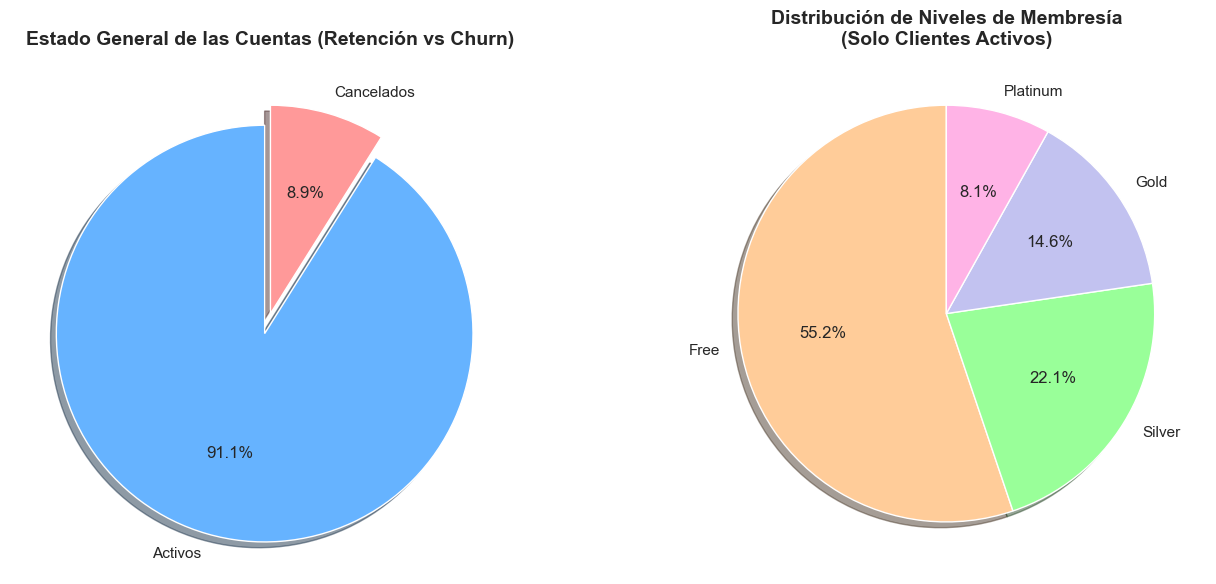

In [9]:
# --- ANÁLISIS DE RETENCIÓN Y MEMBRESÍAS ---

# 1. Preparar los datos para el primer gráfico (Estado general de la membresía)
# Asumimos que 0 = Activo (No churned) y 1 = Cancelado (Churned)
churn_counts = df_customers['churned'].value_counts()
labels_churn = ['Activos', 'Cancelados']
colores_churn = ['#66b3ff', '#ff9999'] # Azul claro para activos, rojo/rosado para cancelados

# 2. Preparar los datos para el segundo gráfico (Tipos de membresía SOLO en activos)
clientes_activos = df_customers[df_customers['churned'] == 0]
tier_counts = clientes_activos['membership_tier'].value_counts()
colores_tier = ['#ffcc99', '#99ff99', '#c2c2f0', '#ffb3e6']

# --- CREACIÓN DE LOS GRÁFICOS ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: Tasa de Retención
axes[0].pie(churn_counts, 
            labels=labels_churn, 
            autopct='%1.1f%%', 
            startangle=90, 
            colors=colores_churn,
            explode=(0.1, 0), # Separa un poco la rebanada de activos para destacar
            shadow=True)
axes[0].set_title('Estado General de las Cuentas (Retención vs Churn)', fontsize=14, fontweight='bold')

# Gráfico 2: Tipos de Membresía en clientes activos
axes[1].pie(tier_counts, 
            labels=tier_counts.index, 
            autopct='%1.1f%%', 
            startangle=90, 
            colors=colores_tier,
            shadow=True)
axes[1].set_title('Distribución de Niveles de Membresía\n(Solo Clientes Activos)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

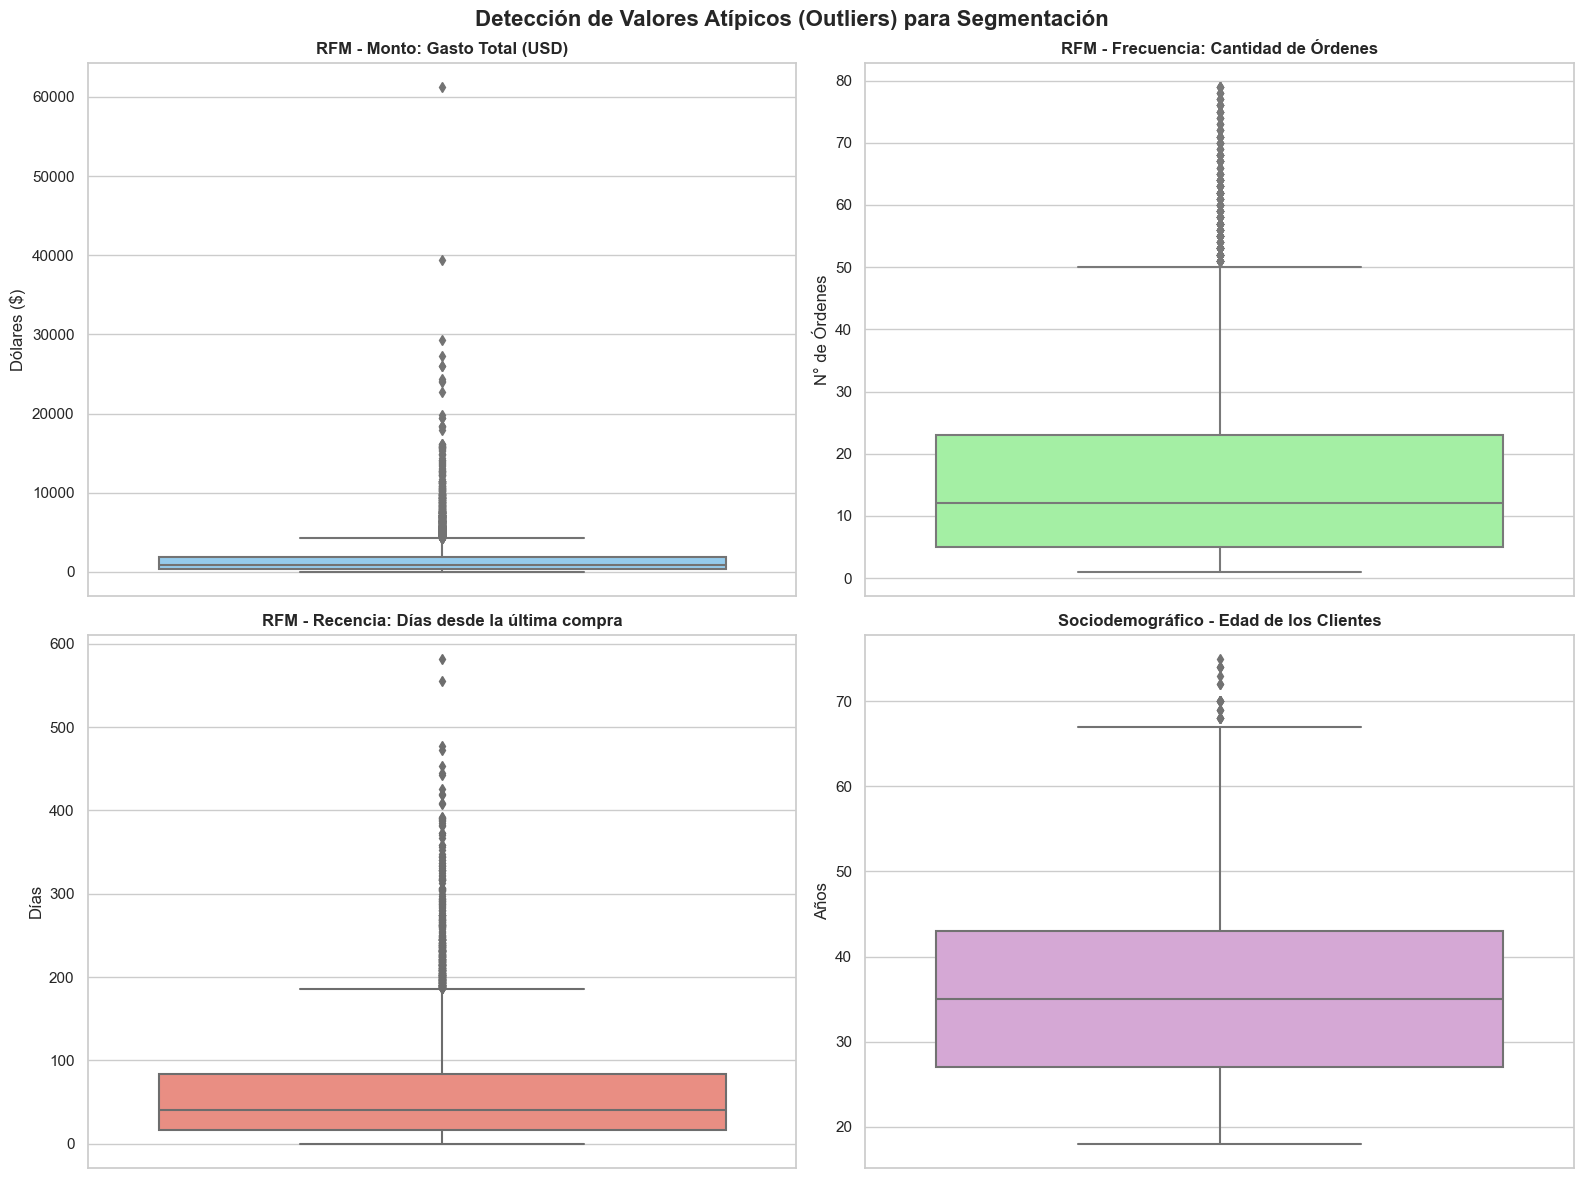

In [10]:
# --- VISUALIZACIÓN DE OUTLIERS: MODELOS RFM Y SOCIODEMOGRÁFICO ---

# Crear una figura con 4 subgráficos (2 filas y 2 columnas)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- 1. MODELO RFM ---

# Monto (Monetary)
sns.boxplot(y=df_customers['total_spend_usd'], ax=axes[0, 0], color='#87CEFA')
axes[0, 0].set_title('RFM - Monto: Gasto Total (USD)', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Dólares ($)')

# Frecuencia (Frequency)
sns.boxplot(y=df_customers['total_orders'], ax=axes[0, 1], color='#98FB98')
axes[0, 1].set_title('RFM - Frecuencia: Cantidad de Órdenes', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('N° de Órdenes')

# Recencia (Recency)
sns.boxplot(y=df_customers['days_since_last_purchase'], ax=axes[1, 0], color='#FA8072')
axes[1, 0].set_title('RFM - Recencia: Días desde la última compra', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Días')


# --- 2. MODELO SOCIODEMOGRÁFICO ---

# Edad (Age)
sns.boxplot(y=df_customers['age'], ax=axes[1, 1], color='#DDA0DD')
axes[1, 1].set_title('Sociodemográfico - Edad de los Clientes', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Años')

# Ajustes visuales generales
plt.suptitle('Detección de Valores Atípicos (Outliers) para Segmentación', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### 3) Tratamiento de datos 

In [11]:
# --- 1. TRATAMIENTO DE EDAD: Agrupación en Rangos (Discretización) ---

# Definimos los límites (bins)
# Empezamos en 17 para que el 18 quede incluido, y terminamos en 100 para abarcar el límite de 75
bins_edad = [17, 25, 35, 45, 55, 100]

# Definimos las etiquetas que nos pediste
etiquetas_edad = ['18-25', '26-35', '36-45', '46-55', '56+']

# Aplicamos la segmentación a la columna original 'age'
df_customers['age_group'] = pd.cut(df_customers['age'], 
                                   bins=bins_edad, 
                                   labels=etiquetas_edad, 
                                   right=True) # right=True incluye el número final del rango

# Revisamos cómo quedó distribuida la base de datos
print("Distribución por los nuevos grupos de Edad:")
# Usamos sort_index() para que se muestren en el orden lógico de las edades
display(df_customers['age_group'].value_counts().sort_index())


# --- 2. TRATAMIENTO DE PAÍSES: Agrupación por Continentes ---

# Creamos un diccionario mapeando los países de su base de datos a continentes.
# (Asegúrense de agregar otros países si su base los contiene)
mapeo_continentes = {
    'United States': 'Norteamérica',
    'Canada': 'Norteamérica',
    'Brazil': 'Sudamérica',
    'Argentina': 'Sudamérica',
    'Chile': 'Sudamérica',
    'United Kingdom': 'Europa',
    'Germany': 'Europa',
    'France': 'Europa',
    'Spain': 'Europa',
    'Italy': 'Europa',
    'India': 'Asia',
    'China': 'Asia',
    'Japan': 'Asia',
    'Australia': 'Oceanía'
    # Pueden agregar más mapeos aquí según los países que salgan en su dataset
}

# Creamos la nueva columna mapeando el diccionario.
# Los países que no estén en el diccionario quedarán como 'Otros'
df_customers['continent'] = df_customers['country'].map(mapeo_continentes).fillna('Otros')

print("\nDistribución por Continentes:")
display(df_customers['continent'].value_counts())

Distribución por los nuevos grupos de Edad:


age_group
18-25    1667
26-35    2442
36-45    2344
46-55    1190
56+       357
Name: count, dtype: int64


Distribución por Continentes:


continent
Norteamérica    2918
Europa          2239
Otros           1201
Asia             949
Sudamérica       370
Oceanía          323
Name: count, dtype: int64

#### MODELO RFM:
##### - Si utilizarán K-means, entonces tienen que considerar la estandarización de los datos de resencia, frecuencia y Dinero. 
##### - Si utilizarán clase latente, se recomienda volver a categoricas. Ej: Recencia: Activo (compró hace poco), En Riesgo, Dormido. Frecuencia: Compra Única (1 sola vez), Ocasional, Frecuente. Monto: Usaremos los cuartiles (Q1, Q2, Q3) para dividirlos matemáticamente en Gasto Bajo, Medio y Alto.

#### MODELO SOCIODEMOGRÁFICO 
##### - No se recomienda usar k-means por los tipos de dato (Si encuentran una buena idea la dicen)
##### - Clase Latente es mejor opción. ver si existen más tipos de categorización que ayuden a ajustar mejor el modelo.

In [13]:
from sklearn.preprocessing import StandardScaler

# --- ESTANDARIZACIÓN Z-SCORE PARA MODELO RFM ---

# 1. Seleccionamos las columnas continuas del RFM
columnas_rfm = ['days_since_last_purchase', 'total_orders', 'total_spend_usd']

# 2. Instanciamos el escalador de scikit-learn
scaler = StandardScaler()

# 3. Ajustamos y transformamos los datos, guardándolos en nuevas columnas (con sufijo '_z')
columnas_z = ['recency_z', 'frequency_z', 'monetary_z']
df_customers[columnas_z] = scaler.fit_transform(df_customers[columnas_rfm])

# 4. Verificación de calidad: 
# Si el Z-score funcionó, la media (mean) debe ser muy cercana a 0 
# y la desviación estándar (std) debe ser exactamente 1.
print("Estadísticas de las variables estandarizadas:")
display(df_customers[columnas_z].describe().round(3))

Estadísticas de las variables estandarizadas:


,recency_z,frequency_z,monetary_z
count,8000.000,8000.000,8000.000
mean,0.000,0.000,-0.000
std,1.000,1.000,1.000
min,-0.983,-1.059,-0.680
25%,-0.719,-0.786,-0.535
50%,-0.307,-0.310,-0.312
75%,0.403,0.440,0.146
max,8.620,4.254,26.149


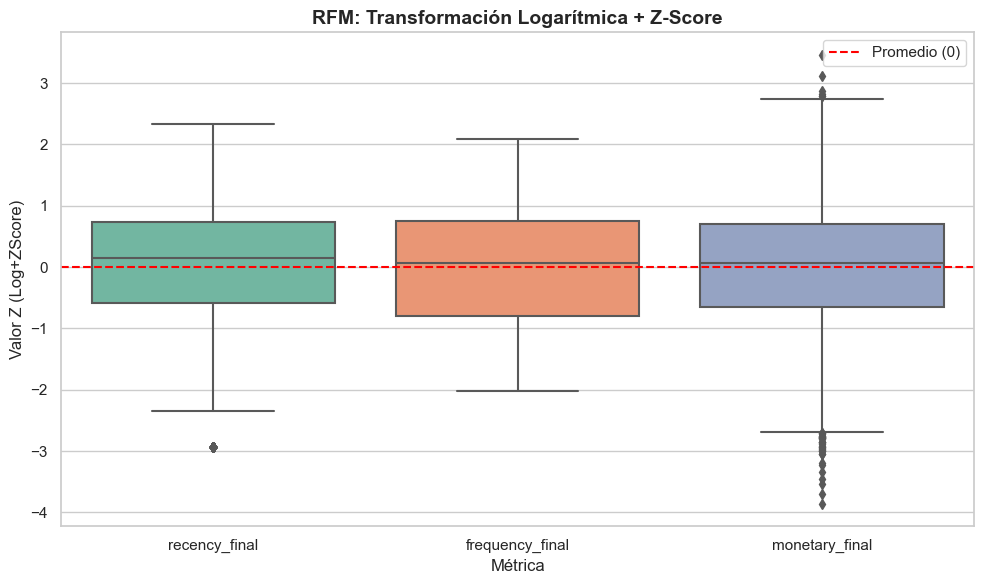

In [15]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# --- 1. TRANSFORMACIÓN LOGARÍTMICA (Para comprimir outliers) ---

# Usamos np.log1p (logaritmo de 1+x) en lugar de np.log para evitar errores si algún valor es 0
columnas_rfm = ['days_since_last_purchase', 'total_orders', 'total_spend_usd']
columnas_log = ['recency_log', 'frequency_log', 'monetary_log']

# Aplicamos el logaritmo
df_customers[columnas_log] = np.log1p(df_customers[columnas_rfm])

# --- 2. ESTANDARIZACIÓN Z-SCORE (Sobre los datos ya logarítmicos) ---

scaler = StandardScaler()
columnas_finales = ['recency_final', 'frequency_final', 'monetary_final']

# Estandarizamos los datos comprimidos
df_customers[columnas_finales] = scaler.fit_transform(df_customers[columnas_log])

# --- 3. VISUALIZAR EL RESULTADO FINAL (Boxplot) ---

# Derretimos el dataframe para graficar
df_long_final = pd.melt(df_customers[columnas_finales], 
                        var_name='Métrica', 
                        value_name='Valor Z (Log+ZScore)')

plt.figure(figsize=(10, 6))
sns.boxplot(x='Métrica', y='Valor Z (Log+ZScore)', data=df_long_final, palette='Set2')
plt.axhline(0, color='red', linestyle='--', label='Promedio (0)')
plt.title('RFM: Transformación Logarítmica + Z-Score', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

### 4) Modelo RFM

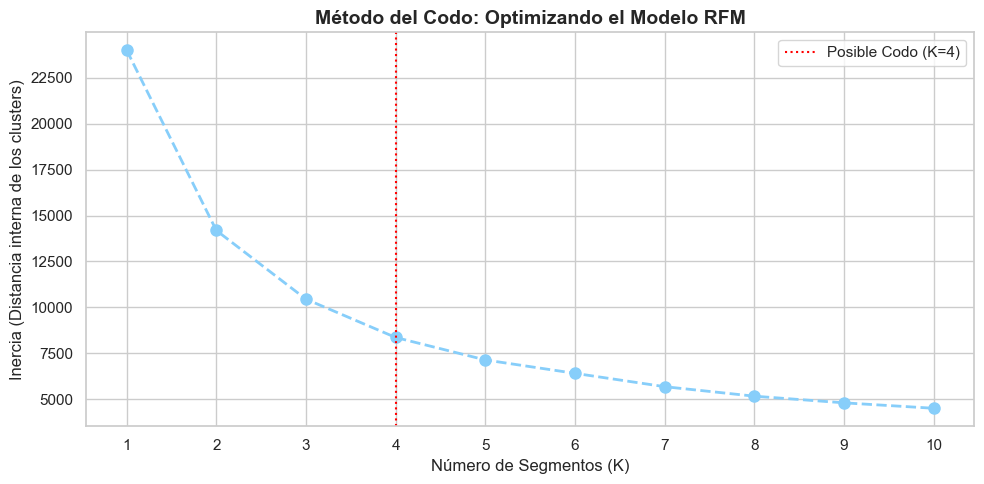


=== PERFIL DE LOS SEGMENTOS RFM ===


,Cantidad_Clientes,Recencia_Promedio_Dias,Frecuencia_Promedio_Ordenes,Gasto_Promedio_USD
Cluster_RFM,,,,
0,3488,81.5,24.9,2514.8
1,1775,8.4,18.8,1641.6
2,2737,64.9,4.5,286.3


In [19]:
from sklearn.cluster import KMeans

# --- 1. PREPARACIÓN DE LOS DATOS ---
# Usamos las variables que ya pasaron por Logaritmo y Z-Score
X_rfm = df_customers[['recency_final', 'frequency_final', 'monetary_final']]


# --- 2. EL MÉTODO DEL CODO (Buscando el K óptimo) ---
inercia = []
rango_k = range(1, 11) # Probaremos de 1 a 10 clusters

for k in rango_k:
    # random_state=42 asegura que a todos en tu equipo les dé el mismo resultado
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_test.fit(X_rfm)
    inercia.append(kmeans_test.inertia_)

# Graficar el codo
plt.figure(figsize=(10, 5))
plt.plot(rango_k, inercia, marker='o', linestyle='--', color='#87CEFA', linewidth=2, markersize=8)
plt.title('Método del Codo: Optimizando el Modelo RFM', fontsize=14, fontweight='bold')
plt.xlabel('Número de Segmentos (K)', fontsize=12)
plt.ylabel('Inercia (Distancia interna de los clusters)', fontsize=12)
plt.xticks(rango_k)
plt.axvline(x=4, color='red', linestyle=':', label='Posible Codo (K=4)') # Sugerencia visual
plt.legend()
plt.tight_layout()
plt.show()


# --- 3. ENTRENAMIENTO DEL MODELO K-MEANS ---
# Basado en la teoría de RFM, 4 clusters suele ser un número ideal (Ej: VIP, Frecuentes, En Riesgo, Perdidos)
# Si tu gráfico del codo muestra un quiebre más claro en 3 o 5, simplemente cambia este número:
k_elegido = 3

modelo_rfm = KMeans(n_clusters=k_elegido, random_state=42, n_init=10)

# El algoritmo asigna un número de grupo (0, 1, 2 o 3) a cada cliente
df_customers['Cluster_RFM'] = modelo_rfm.fit_predict(X_rfm)


# --- 4. INTERPRETACIÓN COMERCIAL (El paso para el 7.0) ---
# Agrupamos a los clientes por su cluster, pero calculamos el promedio de las variables ORIGINALES
# (Porque decirle al gerente "gastan 2.5 en Z-score" no sirve, necesitamos los dólares reales)

resumen_rfm = df_customers.groupby('Cluster_RFM').agg(
    Cantidad_Clientes=('customer_id', 'count'),
    Recencia_Promedio_Dias=('days_since_last_purchase', 'mean'),
    Frecuencia_Promedio_Ordenes=('total_orders', 'mean'),
    Gasto_Promedio_USD=('total_spend_usd', 'mean')
).round(1)

print("\n=== PERFIL DE LOS SEGMENTOS RFM ===")
display(resumen_rfm)

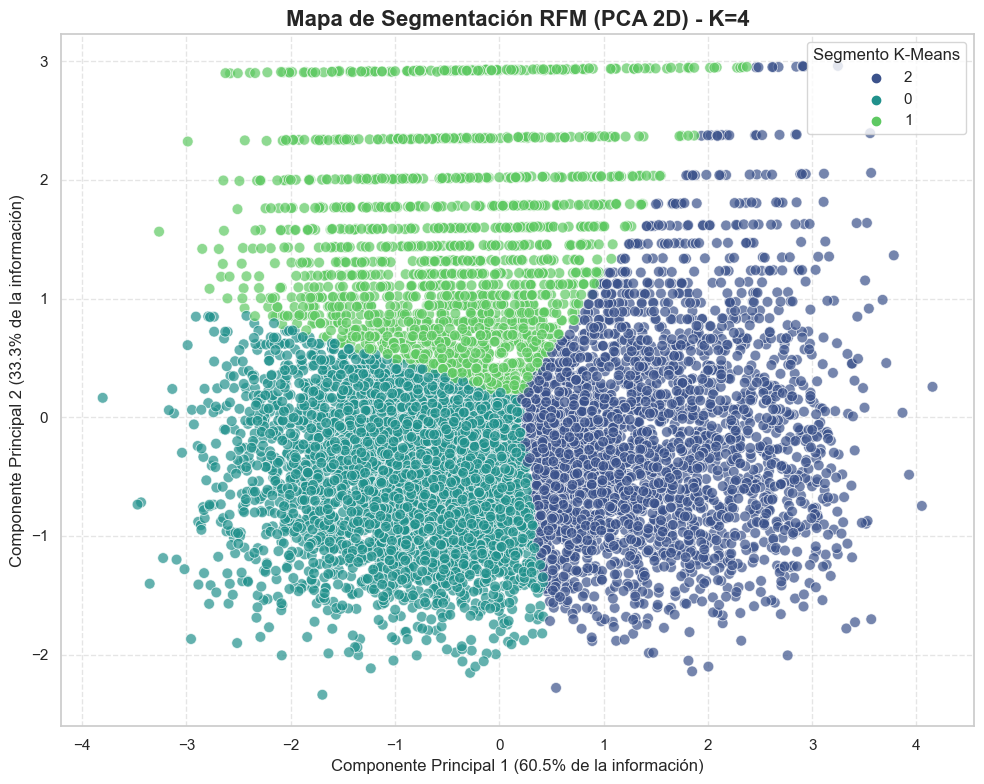

In [20]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# --- 1. ENTRENAR K-MEANS CON K=3 ---
k_elegido = 3
modelo_rfm = KMeans(n_clusters=k_elegido, random_state=42, n_init=10)

# Asumimos que X_rfm ya tiene ['recency_final', 'frequency_final', 'monetary_final']
df_customers['Cluster_RFM'] = modelo_rfm.fit_predict(X_rfm)


# --- 2. APLICAR PCA (Reducción a 2 Dimensiones) ---
pca = PCA(n_components=2)
componentes_principales = pca.fit_transform(X_rfm)

# Creamos un DataFrame temporal solo para el gráfico
df_pca = pd.DataFrame(data=componentes_principales, columns=['PC1', 'PC2'])
df_pca['Cluster'] = df_customers['Cluster_RFM'].astype(str) # Lo pasamos a texto para que los colores sean discretos


# --- 3. GRAFICAR LOS CLUSTERS ---
plt.figure(figsize=(10, 8))

# Usamos Seaborn para un gráfico de dispersión elegante
sns.scatterplot(
    x='PC1', 
    y='PC2',
    hue='Cluster',
    palette='viridis', # Paleta de colores profesional
    data=df_pca,
    alpha=0.7, # Transparencia para ver dónde hay mucha concentración
    s=60       # Tamaño de los puntos
)

# Obtenemos cuánta información original (varianza) logró rescatar PCA
varianza_explicada = pca.explained_variance_ratio_

plt.title('Mapa de Segmentación RFM (PCA 2D) - K=4', fontsize=16, fontweight='bold')
plt.xlabel(f'Componente Principal 1 ({varianza_explicada[0]*100:.1f}% de la información)', fontsize=12)
plt.ylabel(f'Componente Principal 2 ({varianza_explicada[1]*100:.1f}% de la información)', fontsize=12)

plt.legend(title='Segmento K-Means', loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

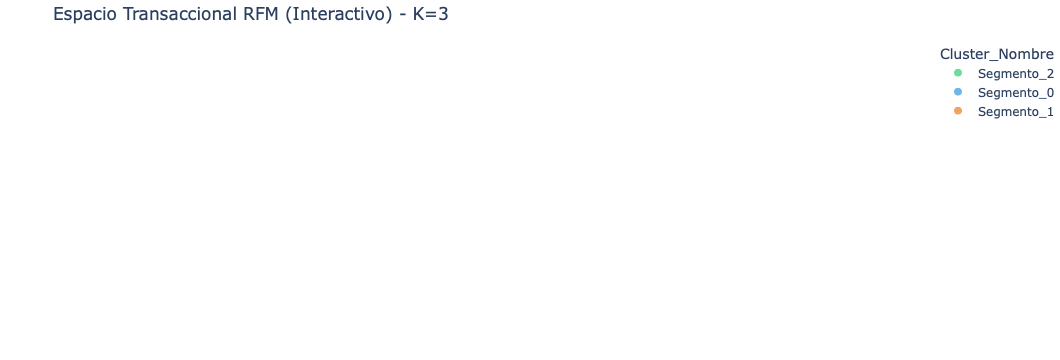

In [21]:
# Instalar plotly si no lo tienen (descomentar la línea de abajo si tira error de que no existe la librería)
# !pip install plotly

import plotly.express as px

# 1. Preparar la columna de clusters (Plotly necesita que sean texto para tratarlos como categorías separadas)
# Asumimos que la columna actual se llama 'Cluster_RFM' y tiene números (0, 1, 2)
df_customers['Cluster_Nombre'] = 'Segmento_' + df_customers['Cluster_RFM'].astype(str)

# 2. Crear el gráfico 3D interactivo
fig_total_3d = px.scatter_3d(
    df_customers,
    x='days_since_last_purchase', # Eje X: Recencia en días reales
    y='total_orders',             # Eje Y: Frecuencia en órdenes reales
    z='total_spend_usd',          # Eje Z: Gasto real en dólares
    color='Cluster_Nombre',       # Colorear según el K-Means
    title='Espacio Transaccional RFM (Interactivo) - K=3',
    hover_data=['customer_id', 'country', 'age'], # ¡Muestra estos datos al pasar el mouse!
    opacity=0.7,
    # Mapa de colores para mantener consistencia visual
    color_discrete_map={
        'Segmento_0': '#3498db', # Azul
        'Segmento_1': '#e67e22', # Naranja
        'Segmento_2': '#2ecc71', # Verde Brillante (Si este es el que más gasta, ¡es tu VIP!)
        'Segmento_3': '#9b59b6'  # (Opcional) Morado por si decides cambiar el modelo a K=4
    }
)

# 3. Ajustes de diseño y etiquetas
fig_total_3d.update_layout(
    scene = dict(
        xaxis_title='Recencia (Días inactivo)',
        yaxis_title='Frecuencia (Total Órdenes)',
        zaxis_title='Monto (Gasto en USD)'
    ),
    margin=dict(r=0, l=0, b=0, t=40),
    template='plotly_white' # Fondo blanco limpio y profesional
)

# Mostrar el gráfico interactivo
fig_total_3d.show()

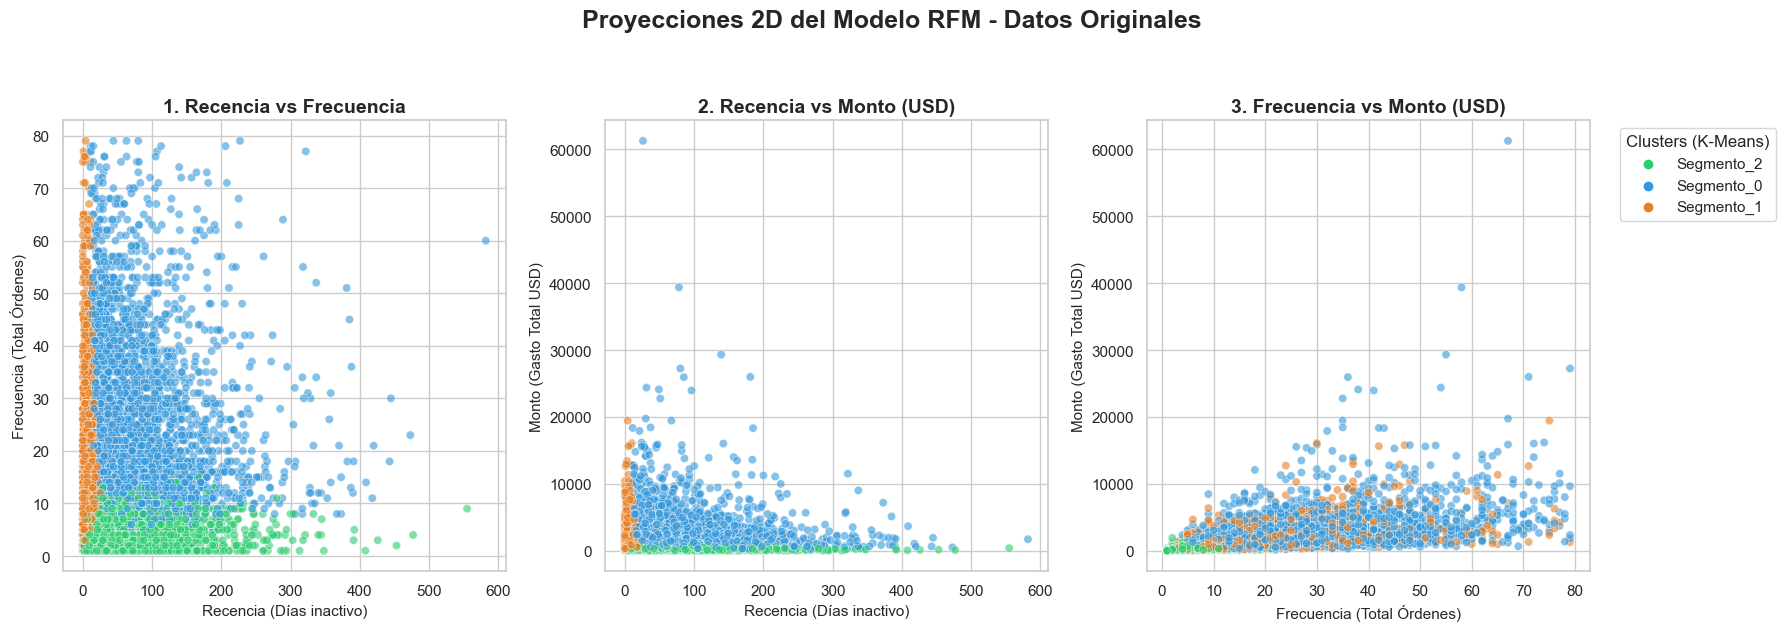

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- VISUALIZACIÓN 2D: LAS 3 CARAS DEL MODELO RFM (DATOS ORIGINALES) ---

# Creamos una figura ancha con 3 subgráficos (1 fila, 3 columnas)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Definimos la misma paleta de colores para mantener consistencia visual con tu gráfico 3D
paleta_clusters = {
    'Segmento_0': '#3498db', # Azul
    'Segmento_1': '#e67e22', # Naranja
    'Segmento_2': '#2ecc71', # Verde Brillante (VIP)
    'Segmento_3': '#9b59b6', # Morado (Si decides usar K=4)
    'Segmento_4': '#393E41'
}

# 1. Primera cara: Recencia vs Frecuencia
sns.scatterplot(
    data=df_customers, 
    x='days_since_last_purchase', 
    y='total_orders', 
    hue='Cluster_Nombre', 
    palette=paleta_clusters, 
    alpha=0.6, 
    ax=axes[0]
)
axes[0].set_title('1. Recencia vs Frecuencia', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Recencia (Días inactivo)', fontsize=11)
axes[0].set_ylabel('Frecuencia (Total Órdenes)', fontsize=11)
axes[0].get_legend().remove() # Quitamos la leyenda para que no estorbe (la dejaremos solo en el último)

# 2. Segunda cara: Recencia vs Monto
sns.scatterplot(
    data=df_customers, 
    x='days_since_last_purchase', 
    y='total_spend_usd', 
    hue='Cluster_Nombre', 
    palette=paleta_clusters, 
    alpha=0.6, 
    ax=axes[1]
)
axes[1].set_title('2. Recencia vs Monto (USD)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Recencia (Días inactivo)', fontsize=11)
axes[1].set_ylabel('Monto (Gasto Total USD)', fontsize=11)
axes[1].get_legend().remove()

# 3. Tercera cara: Frecuencia vs Monto
sns.scatterplot(
    data=df_customers, 
    x='total_orders', 
    y='total_spend_usd', 
    hue='Cluster_Nombre', 
    palette=paleta_clusters, 
    alpha=0.6, 
    ax=axes[2]
)
axes[2].set_title('3. Frecuencia vs Monto (USD)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Frecuencia (Total Órdenes)', fontsize=11)
axes[2].set_ylabel('Monto (Gasto Total USD)', fontsize=11)
axes[2].legend(title='Clusters (K-Means)', bbox_to_anchor=(1.05, 1), loc='upper left') # Leyenda fuera del gráfico

# Título general del panel
plt.suptitle('Proyecciones 2D del Modelo RFM - Datos Originales', fontsize=18, fontweight='bold', y=1.05)

plt.tight_layout()
plt.show()

In [100]:
# Gráfico 3D mostrando los datos estandarizados matemáticamente
fig_total_3d_estandarizado = px.scatter_3d(
    df_customers,
    x='recency_final',       # Usando las variables con Log + Z-Score
    y='frequency_final',     # Usando las variables con Log + Z-Score
    z='monetary_final',      # Usando las variables con Log + Z-Score
    color='Cluster_Nombre', 
    title='Espacio Transaccional RFM (Datos Estandarizados)',
    hover_data=['customer_id', 'total_spend_usd'], # Mostramos el gasto real al pasar el mouse
    opacity=0.7
)
fig_total_3d_estandarizado.show()

### 5) Modelo Sociodemográfico con K-means

In [101]:
# --- 1. SELECCIÓN DE VARIABLES LIMPIAS ---
cols_socio_clean = ['age_group', 'continent', 'gender', 'preferred_device', 'acquisition_channel']

# --- 2. CODIFICACIÓN (One-Hot) ---
# Usamos estas variables para crear la matriz sin nada de RFM
df_socio_limpio = pd.get_dummies(df_customers[cols_socio_clean])

# --- 3. CORRER K-MEANS SOBRE ESTA MATRIZ ---
# Como ahora todo son categorías (0/1), el resultado será mucho más puro
k_socio = 4 
modelo_socio_limpio = KMeans(n_clusters=k_socio, random_state=42, n_init=10)
df_customers['Cluster_Socio_Limpio'] = modelo_socio_limpio.fit_predict(df_socio_limpio)

# --- 4. PERFILAMIENTO ESTRATÉGICO ---
print("Perfil sociodemográfico puro:")
display(df_customers.groupby('Cluster_Socio_Limpio')[cols_socio_clean].agg(lambda x: x.mode()[0]))

Perfil sociodemográfico puro:


,age_group,continent,gender,preferred_device,acquisition_channel
Cluster_Socio_Limpio,,,,,
0,26-35,Norteamérica,Female,Mobile,Organic Search
1,26-35,Norteamérica,Male,Mobile,Organic Search
2,26-35,Norteamérica,Female,Desktop,Organic Search
3,26-35,Norteamérica,Male,Desktop,Organic Search


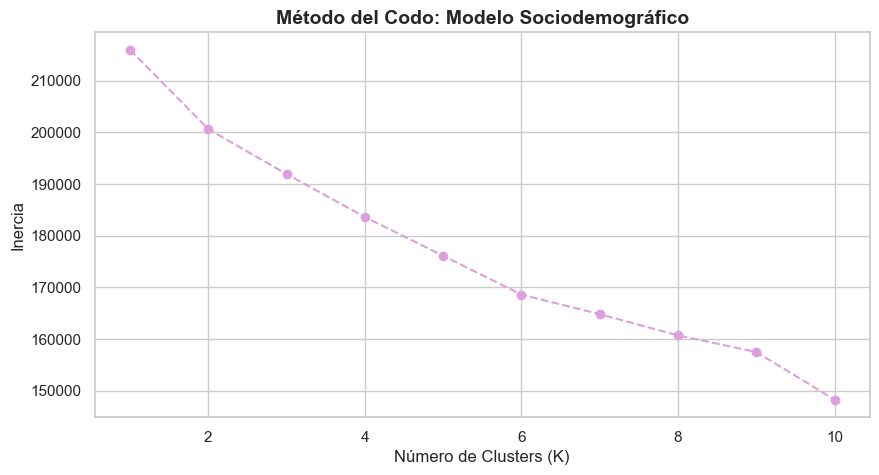

In [102]:
# --- 1. PREPARACIÓN DE MATRIZ SOCIODEMOGRÁFICA ---
# Filtramos solo las variables sociodemográficas seleccionadas
cols_socio = ['age_group', 'continent', 'gender', 'membership_tier', 'preferred_device', 'acquisition_channel']

# Usamos get_dummies para convertir todo a numérico (One-Hot Encoding)
# Esto es obligatorio para que K-Means pueda "medir" la distancia entre categorías
df_socio_encoded = pd.get_dummies(df_customers[cols_socio])

# Importante: Estandarizamos los datos binarios (0 y 1)
# Aunque sean 0/1, es una buena práctica para asegurar que ninguna variable predomine por error
from sklearn.preprocessing import StandardScaler
scaler_socio = StandardScaler()
X_socio = scaler_socio.fit_transform(df_socio_encoded)

# --- 2. MÉTODO DEL CODO (Definiendo el K óptimo) ---
inercia_socio = []
rango_k = range(1, 11)

for k in rango_k:
    kmeans_socio = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_socio.fit(X_socio)
    inercia_socio.append(kmeans_socio.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(rango_k, inercia_socio, marker='o', color='#DDA0DD', linestyle='--')
plt.title('Método del Codo: Modelo Sociodemográfico', fontsize=14, fontweight='bold')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inercia')
plt.show()

In [103]:
# --- 3. ENTRENAMIENTO Y PERFILAMIENTO ---
k_socio = 4 # <--- AJUSTA SEGÚN TU GRÁFICO DEL CODO
modelo_socio = KMeans(n_clusters=k_socio, random_state=42, n_init=10)
df_customers['Cluster_Socio'] = modelo_socio.fit_predict(X_socio)

# --- 4. EXPORTAR PERFILES PARA TU INFORME ---
# Esto te dará una tabla con los grupos y sus características principales
perfil_socio = df_customers.groupby('Cluster_Socio')[cols_socio].agg(lambda x: x.mode()[0])
perfil_socio['Cantidad_Clientes'] = df_customers.groupby('Cluster_Socio').size()

print("\n=== PERFIL DE LOS SEGMENTOS SOCIODEMOGRÁFICOS ===")
display(perfil_socio)


=== PERFIL DE LOS SEGMENTOS SOCIODEMOGRÁFICOS ===


,age_group,continent,gender,membership_tier,preferred_device,acquisition_channel,Cantidad_Clientes
Cluster_Socio,,,,,,,
0,26-35,Norteamérica,Female,Free,Tablet,Organic Search,990
1,26-35,Norteamérica,Female,Free,Mobile,Organic Search,2171
2,26-35,Norteamérica,Male,Free,Mobile,Organic Search,2180
3,26-35,Norteamérica,Male,Free,Desktop,Organic Search,2659


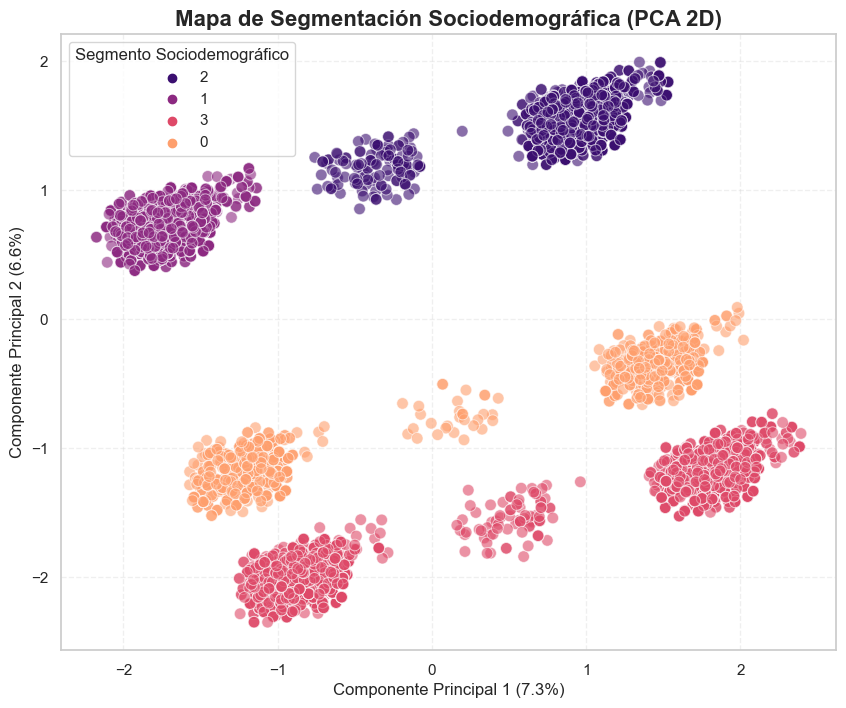

In [104]:
from sklearn.decomposition import PCA

# --- 1. PCA PARA MODELO SOCIODEMOGRÁFICO ---
# Usamos X_socio (la matriz que escalamos antes con StandardScaler)
pca_socio = PCA(n_components=2)
componentes_socio = pca_socio.fit_transform(X_socio)

# Crear DataFrame para el gráfico
df_pca_socio = pd.DataFrame(data=componentes_socio, columns=['PC1', 'PC2'])
df_pca_socio['Cluster'] = df_customers['Cluster_Socio'].astype(str)

# --- 2. GRAFICAR ---
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PC1', 
    y='PC2',
    hue='Cluster',
    palette='magma', # Usamos una paleta distinta para diferenciarlo del RFM
    data=df_pca_socio,
    alpha=0.6,
    s=70
)

# Cálculo de varianza explicada para tu informe técnico
varianza_socio = pca_socio.explained_variance_ratio_

plt.title('Mapa de Segmentación Sociodemográfica (PCA 2D)', fontsize=16, fontweight='bold')
plt.xlabel(f'Componente Principal 1 ({varianza_socio[0]*100:.1f}%)', fontsize=12)
plt.ylabel(f'Componente Principal 2 ({varianza_socio[1]*100:.1f}%)', fontsize=12)
plt.legend(title='Segmento Sociodemográfico')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

In [105]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder

# --- 1. SELECCIÓN Y CONFIGURACIÓN DE VARIABLES ---
# Variables con orden jerárquico (Usaremos Label Encoding)
cols_ordinales = ['membership_tier'] 

# Variables sin orden (Usaremos One-Hot Encoding)
cols_nominales = ['country', 'gender', 'preferred_device', 'acquisition_channel']

# --- 2. APLICAR TRANSFORMACIONES ---
df_socio_final = df_customers.copy()

# A. Label Encoding (para las ordinales)
le = LabelEncoder()
# Mapeo manual para asegurar que Free < Silver < Gold < Platinum (Ajusta según tus valores únicos)
# Si te da error, imprime df_customers['membership_tier'].unique() para ver los nombres exactos
mapping_membership = {'Free': 0, 'Silver': 1, 'Gold': 2, 'Platinum': 3}
df_socio_final['membership_tier_encoded'] = df_socio_final['membership_tier'].map(mapping_membership)

# B. One-Hot Encoding (para las nominales)
df_socio_final = pd.get_dummies(df_socio_final, columns=cols_nominales)

# --- 3. PREPARACIÓN DE LA MATRIZ FINAL ---
# Seleccionamos las columnas que usaremos para el K-Means
# Incluimos la numérica 'age' y las codificadas
cols_modelo = ['age', 'membership_tier_encoded'] + [c for c in df_socio_final.columns if any(x in c for x in cols_nominales)]
X_socio_final = df_socio_final[cols_modelo]

# Estandarización obligatoria para K-Means
scaler = StandardScaler()
X_socio_scaled = scaler.fit_transform(X_socio_final)

# --- 4. ENTRENAMIENTO K-MEANS ---
# Aquí puedes poner el K que hayas visto en el codo (ej. K=4)
k_final = 6
kmeans_socio_final = KMeans(n_clusters=k_final, random_state=42, n_init=10)
df_customers['Cluster_Socio_Final'] = kmeans_socio_final.fit_predict(X_socio_scaled)

# --- 5. PERFILAMIENTO ESTRATÉGICO ---
# Vemos los promedios por cluster para caracterizar
perfil_final = df_customers.groupby('Cluster_Socio_Final')[['age', 'membership_tier', 'country', 'preferred_device', 'acquisition_channel']].agg(lambda x: x.mode()[0])
perfil_final['Cantidad_Clientes'] = df_customers.groupby('Cluster_Socio_Final').size()

print("\n=== PERFIL DE LOS SEGMENTOS SOCIODEMOGRÁFICOS (MODELO HÍBRIDO) ===")
display(perfil_final)


=== PERFIL DE LOS SEGMENTOS SOCIODEMOGRÁFICOS (MODELO HÍBRIDO) ===


,age,membership_tier,country,preferred_device,acquisition_channel,Cantidad_Clientes
Cluster_Socio_Final,,,,,,
0,18,Free,United Kingdom,Mobile,Organic Search,800
1,18,Free,Australia,Mobile,Social Media,323
2,18,Free,United States,Mobile,Organic Search,3706
3,18,Free,United States,Tablet,Organic Search,841
4,18,Free,United States,Desktop,Organic Search,2254
5,18,Free,Turkey,Mobile,Email Campaign,76


In [106]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1. Creamos la columna de forma segura directamente en el dataframe principal
# Asegúrate de que los nombres de los niveles coincidan exactamente con tu CSV
mapping_membership = {'Free': 0, 'Silver': 1, 'Gold': 2, 'Platinum': 3}
df_customers['membership_tier_encoded'] = df_customers['membership_tier'].map(mapping_membership)

# 2. Definimos las columnas que queremos codificar (One-Hot)
cols_nominales = ['country', 'gender', 'preferred_device', 'acquisition_channel']

# 3. Creamos el DataFrame de variables dummy (One-Hot)
df_dummies = pd.get_dummies(df_customers[cols_nominales])

# 4. Concatenamos todo en una sola matriz para el modelo
# 'age' es numérica, 'membership_tier_encoded' es la que acabamos de crear, y df_dummies son las categóricas
X_socio_final = pd.concat([df_customers[['age', 'membership_tier_encoded']], df_dummies], axis=1)

# 5. Estandarización obligatoria para K-Means
scaler = StandardScaler()
X_socio_scaled = scaler.fit_transform(X_socio_final)

# ¡Ahora X_socio_scaled ya tiene todo lo necesario y no debería dar error!
print("Matriz lista. Forma de la matriz:", X_socio_scaled.shape)

Matriz lista. Forma de la matriz: (8000, 34)


In [107]:
# Ver si los grupos son realmente distintos en sus variables clave
perfil = df_customers.groupby('Cluster_Socio_Final')[['age', 'membership_tier_encoded']].mean()
print("Diferencias entre clusters:")
display(perfil)

Diferencias entre clusters:


,age,membership_tier_encoded
Cluster_Socio_Final,,
0,35.563750,0.758750
1,35.981424,0.743034
2,35.488127,0.750405
3,35.913199,0.737218
4,35.757320,0.760870
5,33.407895,0.776316


In [108]:
# Multiplicamos la edad y membresía por 2 o 3 para que pesen más que el resto
X_socio_final['age'] = X_socio_final['age'] * 3
X_socio_final['membership_tier_encoded'] = X_socio_final['membership_tier_encoded'] * 3

# Ahora sí, escalamos y corremos K-Means de nuevo
X_socio_scaled = scaler.fit_transform(X_socio_final)
kmeans_socio_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df_customers['Cluster_Socio_Final'] = kmeans_socio_final.fit_predict(X_socio_scaled)

In [109]:
# Ver correlación de cada variable con el Cluster
correlaciones = X_socio_final.corrwith(df_customers['Cluster_Socio_Final'])
print(correlaciones.sort_values(ascending=False))

preferred_device_Mobile               0.799739
country_Australia                     0.031532
country_India                         0.029975
country_Germany                       0.029952
country_South Africa                  0.027276
country_United States                 0.026914
country_Brazil                        0.023099
gender_Female                         0.022401
acquisition_channel_Referral          0.021854
country_South Korea                   0.020236
country_Sweden                        0.018559
country_Mexico                        0.018547
country_Turkey                        0.018090
country_France                        0.017777
country_Canada                        0.012180
country_Netherlands                   0.008687
acquisition_channel_Social Media      0.006752
country_Singapore                     0.004861
acquisition_channel_Paid Ad           0.004657
country_Poland                        0.004341
gender_Other                          0.003357
country_Spain

In [111]:
!pip install stepmix

In [114]:
from stepmix import StepMix
import numpy as np

# 1. Asegúrate de que X_lca sea una matriz numérica (LabelEncoding previo aplicado)
# y que no tenga nulos.
X_lca = np.array(X_lca)

# 2. DEFINICIÓN EXPLÍCITA DEL DESCRIPTOR
# En lugar de pasar una lista, pasamos un diccionario si queremos ser ultra específicos,
# o un string si queremos aplicar el mismo modelo a todas. 
# Para tu caso (mixto: categóricas + continua), usaremos la forma "dict" que es la más robusta:
measurement = {
    'categorical': list(range(len(cat_cols))), # Índices de tus columnas categóricas
    'gaussian': [len(cat_cols)]                # Índice de tu columna continua (la edad)
}

# 3. Inicializar el modelo
model = StepMix(
    n_components=4, 
    measurement=measurement, 
    random_state=42, 
    n_init=5
)

# 4. Ajustar
model.fit(X_lca)
df_customers['Cluster_LCA'] = model.predict(X_lca)

print("¡Modelo LCA ajustado exitosamente!")

ValueError: Items in a nested model description should be dicts.